In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error,r2_score,root_mean_squared_error,mean_absolute_error

In [2]:
main_df = pd.read_csv("/Users/utkuseyithanoglu/Desktop/nyc car crash analysis/utku-explo/clean_crash_data.csv")

In [3]:
main_df

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,...,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
0,2023-11-01,1:29,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,...,0,1,0,Unspecified,4675373,2,0,1,1,Other
1,2021-09-11,9:35,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,...,0,0,0,Unspecified,4456314,5,1,9,0,Car
2,2021-12-14,8:13,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,...,0,0,0,Unspecified,4486609,1,0,8,0,Other
3,2021-12-14,17:05,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,...,0,0,0,Passing Too Closely,4486555,1,0,17,0,Car
4,2021-12-14,8:17,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,...,0,2,0,Unspecified,4486660,1,0,8,1,Car
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2036392,2026-03-03,12:40,BRONX,10453,40.854816,-73.911500,3.0,0.0,0,0,...,0,3,0,Driver Inattention/Distraction,4882931,1,0,12,1,Other
2036393,2026-03-03,19:19,UNKNOWN,0,40.665520,-73.744670,0.0,0.0,0,0,...,0,0,0,Following Too Closely,4882837,1,0,19,0,SUV
2036394,2026-02-28,23:50,MANHATTAN,10002,40.721798,-73.988240,0.0,0.0,0,0,...,0,0,0,Unspecified,4883299,5,1,23,0,SUV
2036395,2026-03-03,22:15,UNKNOWN,0,40.834114,-73.863270,2.0,0.0,0,0,...,0,2,0,Other Vehicular,4883343,1,0,22,1,SUV


In [4]:
main_df.columns

Index(['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE',
       'LONGITUDE', 'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED',
       'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED',
       'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED',
       'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED',
       'CONTRIBUTING FACTOR VEHICLE 1', 'COLLISION_ID', 'day_of_week',
       'is_weekend', 'hour', 'injury_flag', 'vehicle_category'],
      dtype='object')

In [5]:
main_df['datetime'] = pd.to_datetime(main_df['CRASH DATE'] + " " + main_df['CRASH TIME'])

In [6]:
main_df = main_df.drop(columns=['CRASH DATE','CRASH TIME'])

In [7]:
main_df = main_df.set_index('datetime')

In [8]:
main_df

,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
datetime,,,,,,,,,,,,,,,,,,,
2023-11-01 01:29:00,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,0,0,1,0,Unspecified,4675373,2,0,1,1,Other
2021-09-11 09:35:00,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,0,0,0,0,Unspecified,4456314,5,1,9,0,Car
2021-12-14 08:13:00,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,0,0,0,0,Unspecified,4486609,1,0,8,0,Other
2021-12-14 17:05:00,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,0,0,0,0,Passing Too Closely,4486555,1,0,17,0,Car
2021-12-14 08:17:00,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,0,0,2,0,Unspecified,4486660,1,0,8,1,Car
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-03 12:40:00,BRONX,10453,40.854816,-73.911500,3.0,0.0,0,0,0,0,3,0,Driver Inattention/Distraction,4882931,1,0,12,1,Other
2026-03-03 19:19:00,UNKNOWN,0,40.665520,-73.744670,0.0,0.0,0,0,0,0,0,0,Following Too Closely,4882837,1,0,19,0,SUV
2026-02-28 23:50:00,MANHATTAN,10002,40.721798,-73.988240,0.0,0.0,0,0,0,0,0,0,Unspecified,4883299,5,1,23,0,SUV


In [9]:
main_df.resample("H").size().to_frame("crash_count")

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_41179/210064057.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  main_df.resample("H").size().to_frame("crash_count")


,crash_count
datetime,
2012-07-01 00:00:00,15
2012-07-01 01:00:00,11
2012-07-01 02:00:00,14
2012-07-01 03:00:00,17
2012-07-01 04:00:00,7
...,...
2026-03-03 19:00:00,16
2026-03-03 20:00:00,13
2026-03-03 21:00:00,12


In [10]:
main_df

,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category
datetime,,,,,,,,,,,,,,,,,,,
2023-11-01 01:29:00,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,0,0,1,0,Unspecified,4675373,2,0,1,1,Other
2021-09-11 09:35:00,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,0,0,0,0,Unspecified,4456314,5,1,9,0,Car
2021-12-14 08:13:00,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,0,0,0,0,Unspecified,4486609,1,0,8,0,Other
2021-12-14 17:05:00,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,0,0,0,0,Passing Too Closely,4486555,1,0,17,0,Car
2021-12-14 08:17:00,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,0,0,2,0,Unspecified,4486660,1,0,8,1,Car
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-03 12:40:00,BRONX,10453,40.854816,-73.911500,3.0,0.0,0,0,0,0,3,0,Driver Inattention/Distraction,4882931,1,0,12,1,Other
2026-03-03 19:19:00,UNKNOWN,0,40.665520,-73.744670,0.0,0.0,0,0,0,0,0,0,Following Too Closely,4882837,1,0,19,0,SUV
2026-02-28 23:50:00,MANHATTAN,10002,40.721798,-73.988240,0.0,0.0,0,0,0,0,0,0,Unspecified,4883299,5,1,23,0,SUV


In [11]:
hourly_counts = main_df.resample("H").size()
main_df['crash_count'] = main_df.index.floor('H').map(hourly_counts)

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_41179/1881470292.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_counts = main_df.resample("H").size()
/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_41179/1881470292.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  main_df['crash_count'] = main_df.index.floor('H').map(hourly_counts)


In [12]:
main_df

,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,NUMBER OF PERSONS INJURED,NUMBER OF PERSONS KILLED,NUMBER OF PEDESTRIANS INJURED,NUMBER OF PEDESTRIANS KILLED,NUMBER OF CYCLIST INJURED,NUMBER OF CYCLIST KILLED,NUMBER OF MOTORIST INJURED,NUMBER OF MOTORIST KILLED,CONTRIBUTING FACTOR VEHICLE 1,COLLISION_ID,day_of_week,is_weekend,hour,injury_flag,vehicle_category,crash_count
datetime,,,,,,,,,,,,,,,,,,,,
2023-11-01 01:29:00,BROOKLYN,11230,40.621790,-73.970024,1.0,0.0,0,0,0,0,1,0,Unspecified,4675373,2,0,1,1,Other,4
2021-09-11 09:35:00,BROOKLYN,11208,40.667202,-73.866500,0.0,0.0,0,0,0,0,0,0,Unspecified,4456314,5,1,9,0,Car,8
2021-12-14 08:13:00,BROOKLYN,11233,40.683304,-73.917274,0.0,0.0,0,0,0,0,0,0,Unspecified,4486609,1,0,8,0,Other,28
2021-12-14 17:05:00,UNKNOWN,0,40.709183,-73.956825,0.0,0.0,0,0,0,0,0,0,Passing Too Closely,4486555,1,0,17,0,Car,23
2021-12-14 08:17:00,BRONX,10475,40.868160,-73.831480,2.0,0.0,0,0,0,0,2,0,Unspecified,4486660,1,0,8,1,Car,28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-03 12:40:00,BRONX,10453,40.854816,-73.911500,3.0,0.0,0,0,0,0,3,0,Driver Inattention/Distraction,4882931,1,0,12,1,Other,4
2026-03-03 19:19:00,UNKNOWN,0,40.665520,-73.744670,0.0,0.0,0,0,0,0,0,0,Following Too Closely,4882837,1,0,19,0,SUV,16
2026-02-28 23:50:00,MANHATTAN,10002,40.721798,-73.988240,0.0,0.0,0,0,0,0,0,0,Unspecified,4883299,5,1,23,0,SUV,7


In [22]:
main_df['crash_count']

datetime
2023-11-01 01:29:00     4
2021-09-11 09:35:00     8
2021-12-14 08:13:00    28
2021-12-14 17:05:00    23
2021-12-14 08:17:00    28
                       ..
2026-03-03 12:40:00     4
2026-03-03 19:19:00    16
2026-02-28 23:50:00     7
2026-03-03 22:15:00     8
2026-03-03 04:25:00     1
Name: crash_count, Length: 2036397, dtype: int64

<Axes: xlabel='BOROUGH', ylabel='crash_count'>

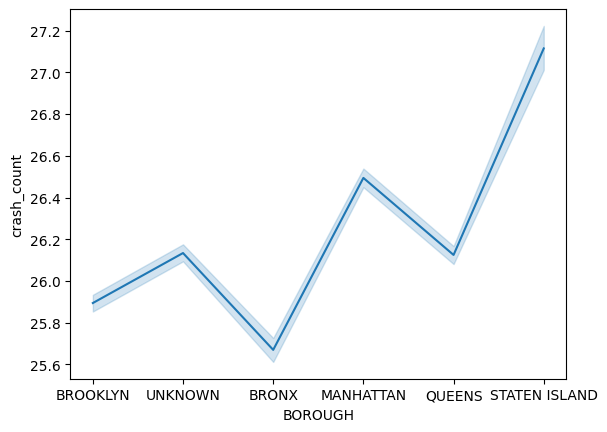

In [23]:
sns.lineplot(data=main_df,x='BOROUGH',y='crash_count')

<Axes: xlabel='BOROUGH', ylabel='crash_count'>

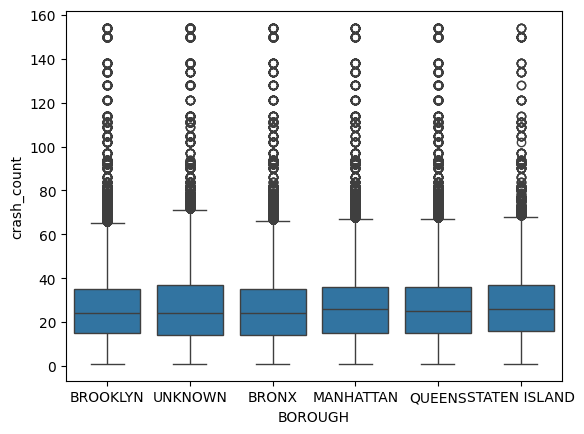

In [24]:
sns.boxplot(data=main_df,x='BOROUGH',y='crash_count')

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60],
 [Text(0, 0, 'Unspecified'),
  Text(1, 0, 'Passing Too Closely'),
  Text(2, 0, 'Driver Inexperience'),
  Text(3, 0, 'Passing or Lane Usage Improper'),
  Text(4, 0, 'Turning Improperly'),
  Text(5, 0, 'Unsafe Speed'),
  Text(6, 0, 'Reaction to Uninvolved Vehicle'),
  Text(7, 0, 'Steering Failure'),
  Text(8, 0, 'Following Too Closely'),
  Text(9, 0, 'Other Vehicular'),
  Text(10, 0, 'Driver Inattention/Distraction'),
  Text(11, 0, 'Oversized Vehicle'),
  Text(12, 0, 'Traffic Control Disregarded'),
  Text(13, 0, 'Alcohol Involvement'),
  Text(14, 0, 'View Obstructed/Limited'),
  Text(15, 0, 'Failure to Yield Right-of-Way'),
  Text(16, 0,

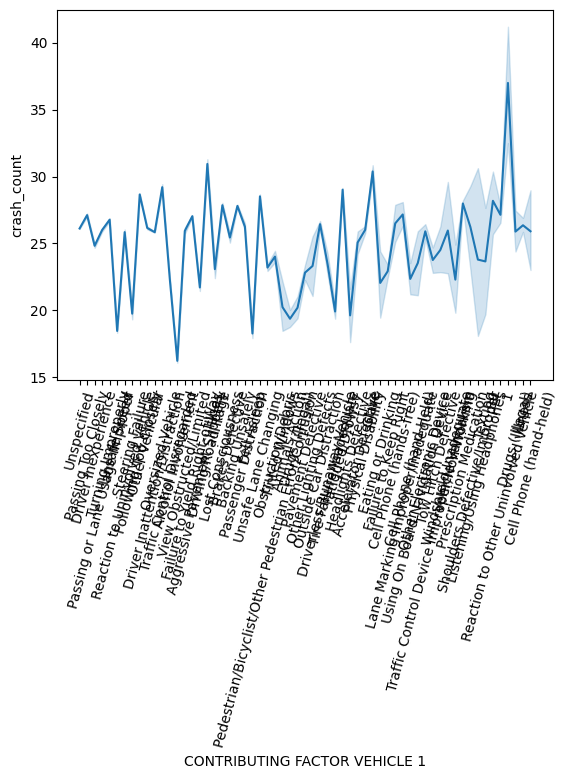

In [30]:
sns.lineplot(data=main_df,x='CONTRIBUTING FACTOR VEHICLE 1',y='crash_count')
plt.xticks(rotation=75)

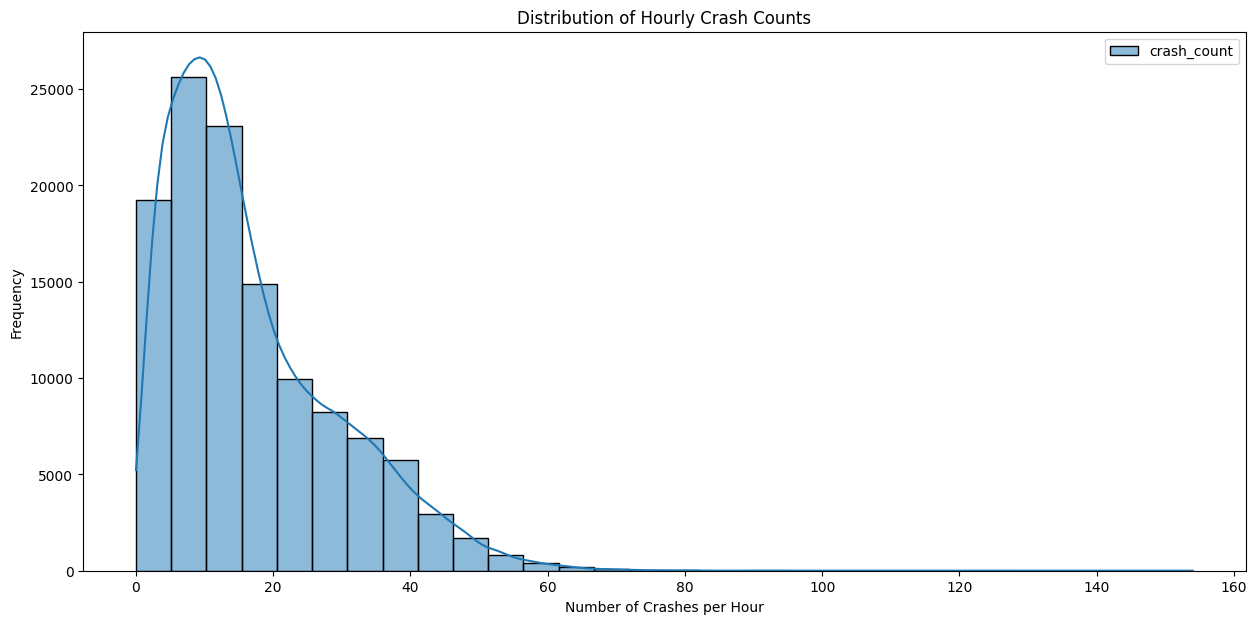

In [33]:
plt.figure(figsize=(15,7))
sns.histplot(time_df, bins=30, kde=True)
plt.title("Distribution of Hourly Crash Counts")
plt.xlabel("Number of Crashes per Hour")
plt.ylabel("Frequency")
plt.show()

In [13]:
time_df = main_df['crash_count']

In [14]:
(time_df.index).min()

Timestamp('2012-07-01 00:05:00')

In [15]:
(time_df.index).max()

Timestamp('2026-03-03 23:53:00')

In [16]:
time_df = main_df.resample("H").size().to_frame("crash_count")

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_41179/1526203536.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_df = main_df.resample("H").size().to_frame("crash_count")


In [ ]:
plt.figure(figsize=(15,7))
sns.histplot(time_df, bins=30, kde=True)
plt.title("Distribution of Hourly Crash Counts")
plt.xlabel("Number of Crashes per Hour")
plt.ylabel("Frequency")
plt.show()

<Axes: xlabel='datetime', ylabel='crash_count'>

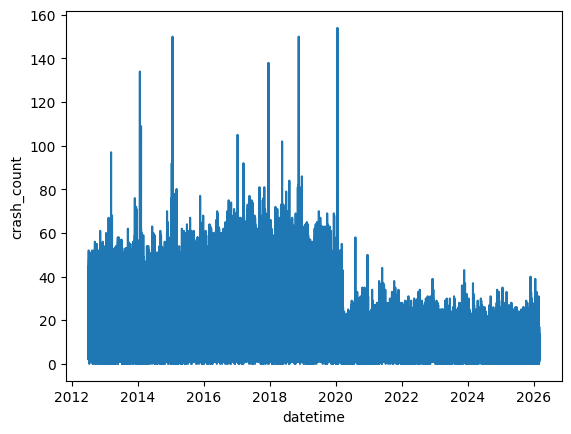

In [17]:
sns.lineplot(data=time_df, x=time_df.index, y="crash_count")


In [18]:
time_df.sort_index

<bound method DataFrame.sort_index of                      crash_count
datetime                        
2012-07-01 00:00:00           15
2012-07-01 01:00:00           11
2012-07-01 02:00:00           14
2012-07-01 03:00:00           17
2012-07-01 04:00:00            7
...                          ...
2026-03-03 19:00:00           16
2026-03-03 20:00:00           13
2026-03-03 21:00:00           12
2026-03-03 22:00:00            8
2026-03-03 23:00:00            3

[119856 rows x 1 columns]>

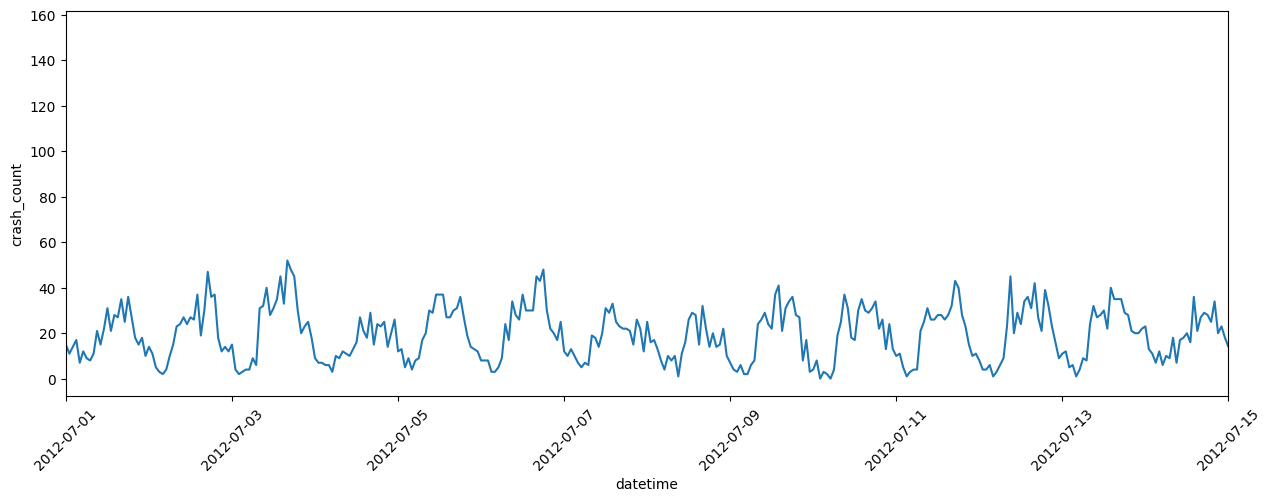

In [19]:
plt.figure(figsize=(15,5))
sns.lineplot(data=time_df, x=time_df.index, y="crash_count")
plt.xlim(pd.Timestamp("2012-07-01"), pd.Timestamp("2012-07-15"))
plt.xticks(rotation=45)
plt.show()

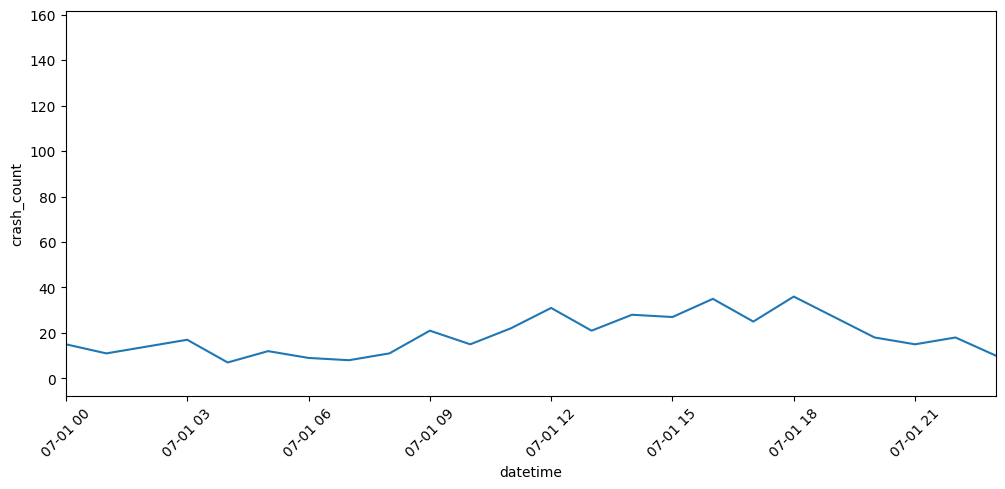

In [20]:
plt.figure(figsize=(12,5))
sns.lineplot(data=time_df, x=time_df.index, y="crash_count")
plt.xlim(pd.Timestamp("2012-07-01 00:00:00"), pd.Timestamp("2012-07-01 23:00:00"))
plt.xticks(rotation=45)
plt.show()

In [21]:
time_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 119856 entries, 2012-07-01 00:00:00 to 2026-03-03 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   crash_count  119856 non-null  int64
dtypes: int64(1)
memory usage: 1.8 MB


In [34]:
time_df['diff']=time_df['crash_count'].diff()

In [35]:
time_df['diff']

datetime
2012-07-01 00:00:00     NaN
2012-07-01 01:00:00    -4.0
2012-07-01 02:00:00     3.0
2012-07-01 03:00:00     3.0
2012-07-01 04:00:00   -10.0
                       ... 
2026-03-03 19:00:00     0.0
2026-03-03 20:00:00    -3.0
2026-03-03 21:00:00    -1.0
2026-03-03 22:00:00    -4.0
2026-03-03 23:00:00    -5.0
Freq: h, Name: diff, Length: 119856, dtype: float64

In [38]:
time_df = time_df.dropna()

In [39]:
time_df['diff']

datetime
2012-07-01 01:00:00    -4.0
2012-07-01 02:00:00     3.0
2012-07-01 03:00:00     3.0
2012-07-01 04:00:00   -10.0
2012-07-01 05:00:00     5.0
                       ... 
2026-03-03 19:00:00     0.0
2026-03-03 20:00:00    -3.0
2026-03-03 21:00:00    -1.0
2026-03-03 22:00:00    -4.0
2026-03-03 23:00:00    -5.0
Freq: h, Name: diff, Length: 119855, dtype: float64

<Axes: xlabel='datetime', ylabel='diff'>

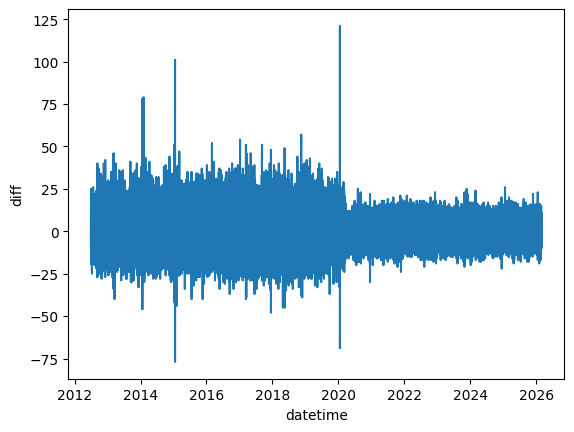

In [40]:
sns.lineplot(data=time_df['diff'])

In [41]:
time_df['diff'].describe()

count    119855.000000
mean         -0.000100
std           7.402412
min         -77.000000
25%          -4.000000
50%           0.000000
75%           4.000000
max         121.000000
Name: diff, dtype: float64

In [42]:
time_df['diff'].nlargest(10)

datetime
2020-01-18 13:00:00    121.0
2015-01-18 07:00:00    101.0
2014-02-03 08:00:00     79.0
2014-01-21 09:00:00     78.0
2018-11-15 14:00:00     57.0
2018-11-15 15:00:00     57.0
2017-01-07 11:00:00     54.0
2016-03-02 08:00:00     52.0
2015-01-09 08:00:00     51.0
2017-03-13 16:00:00     51.0
Name: diff, dtype: float64

(np.float64(18262.0), np.float64(18626.0))

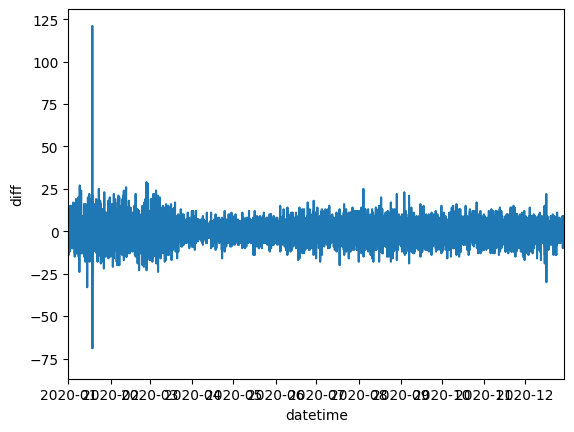

In [44]:
sns.lineplot(data=time_df['diff'])
plt.xlim(pd.to_datetime("2020-01-01"), pd.to_datetime("2020-12-30"))

(np.float64(18262.0), np.float64(18382.0))

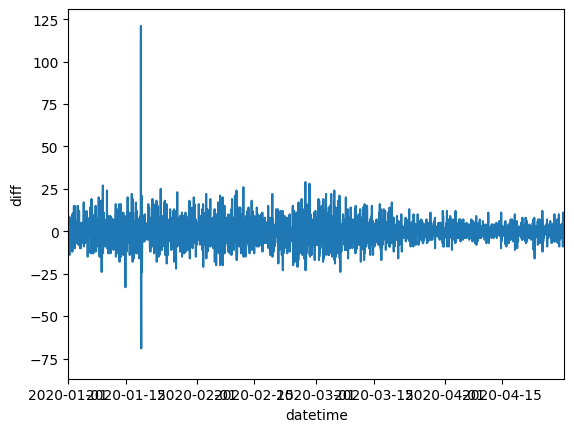

In [45]:
sns.lineplot(data=time_df['diff'])
plt.xlim(pd.to_datetime("2020-01-01"), pd.to_datetime("2020-04-30"))

(np.float64(18262.0), np.float64(18317.0))

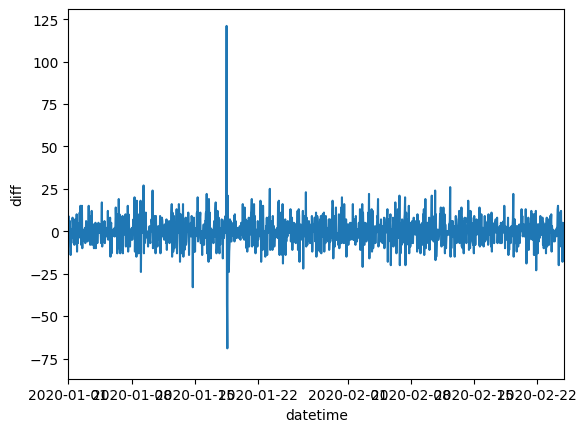

In [47]:
sns.lineplot(data=time_df['diff'])
plt.xlim(pd.to_datetime("2020-01-01"), pd.to_datetime("2020-02-25"))

(np.float64(18276.0), np.float64(18283.0))

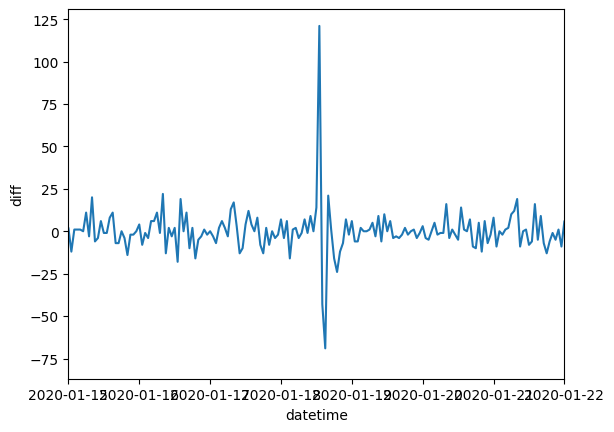

In [51]:
sns.lineplot(data=time_df['diff'])
plt.xlim(pd.to_datetime("2020-01-15"), pd.to_datetime("2020-01-22"))

In [55]:
time_df.sort_values(by='diff', ascending=False).head(5)

,crash_count,diff
datetime,,
2020-01-18 13:00:00,154,121.0
2015-01-18 07:00:00,111,101.0
2014-02-03 08:00:00,109,79.0
2014-01-21 09:00:00,114,78.0
2018-11-15 14:00:00,93,57.0


i detected a few extreme spikes in the differenced series, likely caused by sudden reporting or aggregation effects in the dataset. However, given the large size of the dataset, these points were not removed as they have minimal impact on the overall model performance.

In [53]:
from statsmodels.tsa.stattools import adfuller

In [54]:
result = adfuller(time_df['diff'].dropna())
print("ADF statistic",result[0])
print("p-value:",result[1])

ADF statistic -72.043996963965
p-value: 0.0


In [ ]:
# time series non-stationary
#After applying first-order differencing, 
# we performed the Augmented Dickey-Fuller test to check stationarity.
# The p-value was below 0.05, which indicates that the time series became stationary 
# and suitable for time series modeling.
#
#

In [56]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
## model = additive ==Pattern veriye eklenir

In [57]:
decomposition =seasonal_decompose(time_df['crash_count'],model='additive',period=24)

In [58]:
decomposition

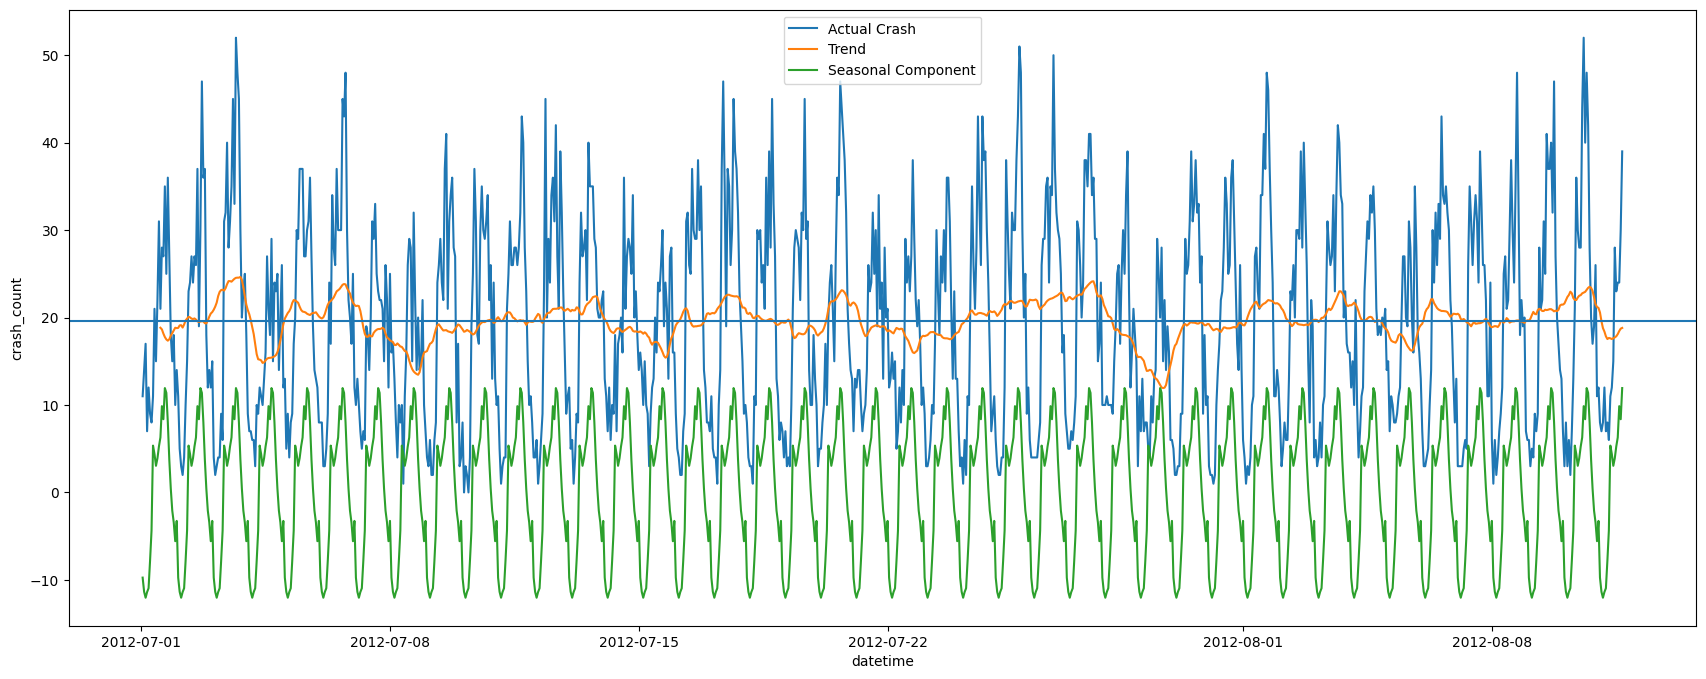

In [59]:
plt.figure(figsize=(21, 8))
sns.lineplot(x=time_df.index[:1000],y=time_df['crash_count'][:1000],label="Actual Crash")
sns.lineplot(x=decomposition.trend.index[:1000], y=decomposition.trend[:1000], label="Trend")
sns.lineplot(decomposition.seasonal[:1000],label="Seasonal Component")
plt.axhline(time_df['crash_count'][:1000].mean(),label="Mean")

"In this graph, we are looking at car crash analysis over time. The blue line represents the actual number of EMS calls. The orange line shows the overall trend in the data. And the green line represents the seasonal component, which highlights the repeating daily patterns in call volume."

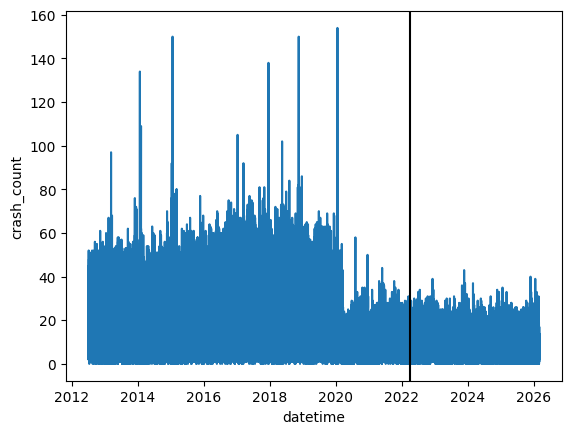

In [63]:
sns.lineplot(data=time_df,x=time_df.index,y='crash_count')
plt.axvline(pd.to_datetime("2022-04-01 12:00:00"), color='black',label='cutoff_date')

In [65]:
time_df['crash_count120'] = time_df['crash_count'].rolling(120).mean()

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_41179/803718235.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_df['crash_count120'] = time_df['crash_count'].rolling(120).mean()


<Axes: xlabel='datetime', ylabel='crash_count120'>

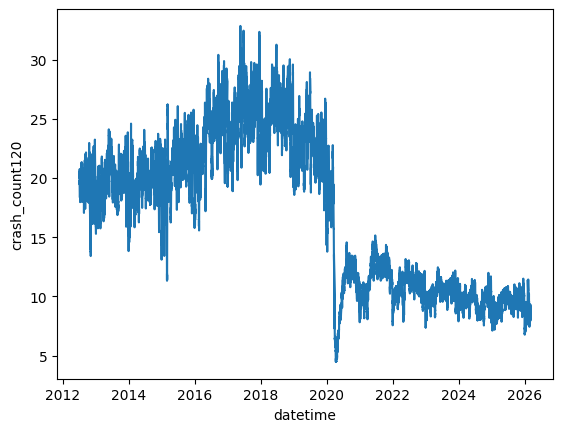

In [67]:
sns.lineplot(data=time_df,x=time_df.index,y='crash_count120')

In [68]:
time_df.resample("Y").sum()

/var/folders/34/1yg1tqgd1b96v45w9k29prnw0000gn/T/ipykernel_41179/3087671501.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  time_df.resample("Y").sum()


,crash_count,diff,crash_count120
datetime,,,
2012-12-31,85444,-2.0,83273.483333
2013-12-31,171941,2.0,171982.225000
2014-12-31,172755,-2.0,172778.166667
2015-12-31,183002,-2.0,182853.025000
2016-12-31,208528,4.0,208323.350000
2017-12-31,221385,-4.0,221370.541667
2018-12-31,220520,22.0,220538.658333
2019-12-31,197735,-20.0,197966.450000
2020-12-31,105885,-4.0,106361.875000


Text(0.5, 1.0, 'NYC Crash Count Trend (120-hour Rolling Average)')

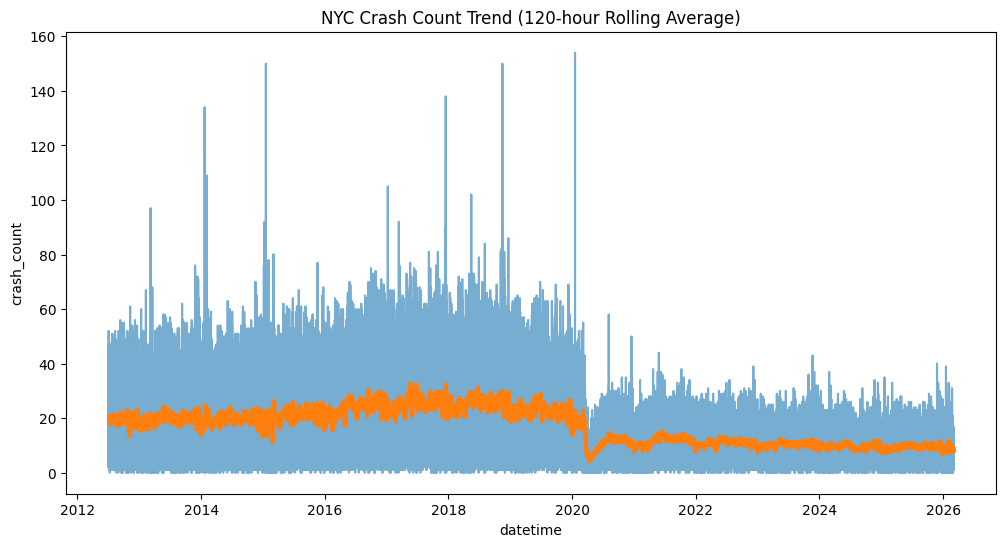

In [71]:
plt.figure(figsize=(12,6))

sns.lineplot(data=time_df, x=time_df.index, y='crash_count', alpha=0.6)
sns.lineplot(data=time_df, x=time_df.index, y='crash_count120', linewidth=3)

plt.title("NYC Crash Count Trend (120-hour Rolling Average)")

In [72]:
split_df = time_df.copy()

In [ ]:
cutoff_date = pd.to_datetime("2022-04-01 12:00:00")


In [74]:
training_set = split_df[split_df.index < cutoff_date]
test_set = split_df[split_df.index >= cutoff_date]


In [75]:
training_set.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 85475 entries, 2012-07-01 01:00:00 to 2022-04-01 11:00:00
Freq: h
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   crash_count     85475 non-null  int64  
 1   diff            85475 non-null  float64
 2   crash_count120  85356 non-null  float64
dtypes: float64(2), int64(1)
memory usage: 2.6 MB


In [76]:
training_set.isna().sum()

crash_count         0
diff                0
crash_count120    119
dtype: int64

In [77]:
training_set = training_set.dropna()

In [78]:
training_set = training_set.drop(columns=['crash_count120'])

In [79]:
training_set.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 85356 entries, 2012-07-06 00:00:00 to 2022-04-01 11:00:00
Freq: h
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   crash_count  85356 non-null  int64  
 1   diff         85356 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 2.0 MB


In [81]:
test_set=test_set.drop(columns=['crash_count120'])

In [82]:
test_set = test_set.dropna()

In [83]:
test_set.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34380 entries, 2022-04-01 12:00:00 to 2026-03-03 23:00:00
Freq: h
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   crash_count  34380 non-null  int64  
 1   diff         34380 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 805.8 KB


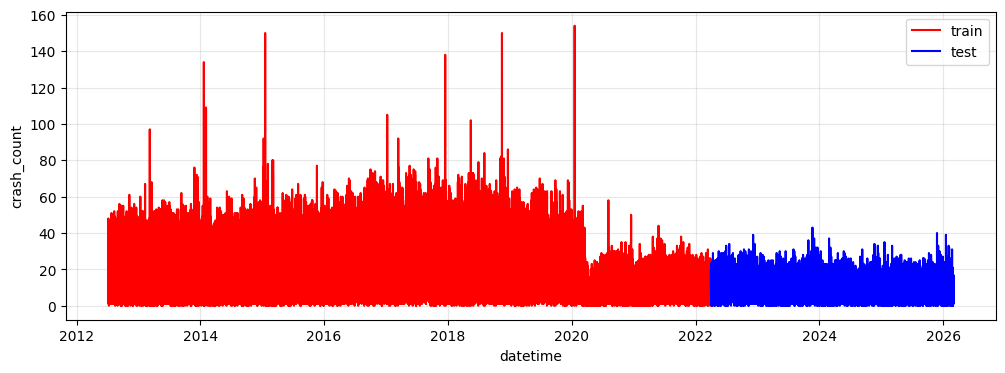

In [84]:
plt.figure(figsize=(12,4))

sns.lineplot(data=training_set, x=training_set.index, y='crash_count', label='train', color='red')
sns.lineplot(data=test_set,  x=test_set.index,  y='crash_count', label='test',  color='blue')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [85]:
training_set=training_set.drop(columns=['diff'])
test_set=test_set.drop(columns=['diff'])

In [87]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(training_set['crash_count'])
print("ADF Statistic:",result[0])
print("p-value",result[1])

ADF Statistic: -12.915383693270455
p-value 3.97621246406884e-24


In [ ]:
## Stationary
#d=0

In [89]:
from statsmodels.tsa.arima.model import ARIMA

In [90]:
model = ARIMA(training_set['crash_count'],order=(1,0,1))

In [92]:
model_fit = model.fit()

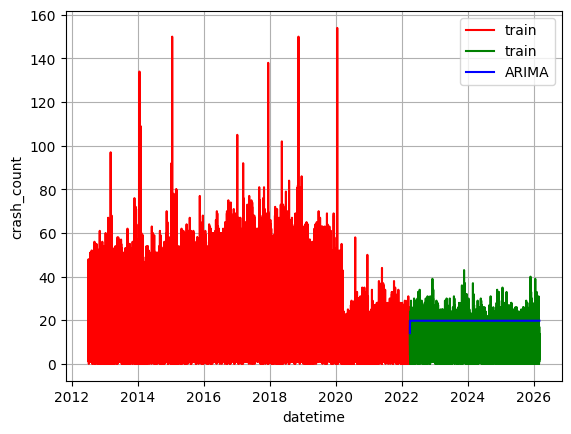

In [96]:
arima_pred = model_fit.get_forecast(steps=len(test_set)).predicted_mean

sns.lineplot(data=training_set,x=training_set.index,y='crash_count',label='train',color='red')
sns.lineplot(data=test_set,x=test_set.index,y='crash_count',label='train',color='green')
sns.lineplot(x=test_set.index,y=arima_pred,color='blue',label='ARIMA')
plt.grid()


In [ ]:
## # ARIMA did not catch the daily pattern, so it gave almost the same prediction every time.


In [100]:
def model_evulation(actual_values,predict_values):
    print(f'root_mean_squared_error :{root_mean_squared_error(actual_values,predict_values)}')
    print(f'mean_squared_error :{mean_squared_error(actual_values,predict_values)}')
    print(f'mean_absolute_error :{mean_absolute_error(actual_values,predict_values)}')
    print(f'r2_score :{r2_score(actual_values,predict_values)}')


In [101]:
model_evulation(test_set,arima_pred)

root_mean_squared_error :11.13104071618282
mean_squared_error :123.90006742531975
mean_absolute_error :10.038258018171797
r2_score :-3.4656271904507046
